In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 1. 读取数据

In [13]:
df = pd.read_csv('Ux.csv')

print(df.head())

       y   y/(L/2)       t=1       t=2       t=3       t=4       t=5  \
0  0.000  0.000000  0.126837  0.727889  1.119750  1.021920  0.987480   
1  0.049  0.685315  0.104943  0.103057  0.889530  0.619280  0.560327   
2  0.081  1.132867  0.115055  0.562763  0.826771  0.782272  0.693005   
3  0.124  1.734266  0.129249  0.770789  1.174720  1.072510  1.033910   
4  0.163  2.279720  0.117880  0.751505  0.887475  0.775352  0.730898   

        t=6       t=7       t=8  ...      t=91      t=92      t=93      t=94  \
0  0.978484  0.988122  1.070280  ...  0.270167  0.272682  0.273296  0.272976   
1  0.544029  0.547001  0.528752  ...  0.077458  0.076757  0.075869  0.075557   
2  0.674755  0.682590  0.683558  ...  0.189201  0.190113  0.189620  0.188825   
3  1.017330  1.029710  1.061750  ...  0.302721  0.306089  0.306635  0.304830   
4  0.712657  0.722205  0.734268  ...  0.197884  0.198056  0.196873  0.195539   

       t=95      t=96      t=97      t=98      t=99     t=100  
0  0.272795  0.273501 

# 2. 绘制图像

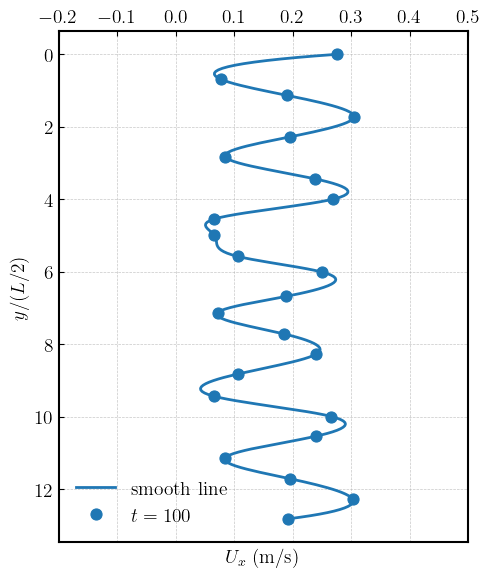

In [39]:
# ===============================
# 数据
# ===============================
x = df["y/(L/2)"].values
t_col = "t=100"
y_t = df[t_col].values

# ===============================
# 画图参数
# ===============================
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    "text.usetex": True
})

fig, ax = plt.subplots(1, figsize=(5, 6))  # 纵向图更合理

# ===============================
# Experiment：插值平滑曲线
# ===============================
if len(x) > 3:
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spl = make_interp_spline(x, y_t, k=3)
    y_t_smooth = spl(x_smooth)

    # ⚠️ 关键：x/y 对调
    ax.plot(
        y_t_smooth, x_smooth,
        linewidth=2,
        linestyle='-',
        label='smooth line'
    )
else:
    ax.plot(
        y_t, x,
        linewidth=2,
        linestyle='none',
        label='smooth line'
    )

# ===============================
# t=120：点线图 + 空心方块
# ===============================
ax.plot(
    y_t, x,
    linewidth=1.2,
    linestyle='none',
    marker='o',
    markersize=8,
    markerfacecolor='#1f77b4',
    markeredgewidth=0.8,
    color='#1f77b4',
    label=rf'$t=100$'
)

# ===============================
# 坐标轴 & 风格
# ===============================
ax.set_xlabel(r'$U_x\;(\mathrm{m/s})$')
ax.set_ylabel(r'$y/(L/2)$')

# ⚠️ 关键设置
ax.invert_yaxis()          # y 轴刻度从上到下
ax.yaxis.tick_left()   # ✔
ax.xaxis.tick_top()    # ✔

ax.xaxis.set_tick_params(direction='in', which='both')
ax.yaxis.set_tick_params(direction='in', which='both')

#ax.set_ylim(1.0, 0.0)          # y 轴范围
ax.set_xlim(-0.2, 0.5)       # x 轴范围

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.legend(
    frameon=False,
    loc='lower left',
)

plt.tight_layout()
plt.show()


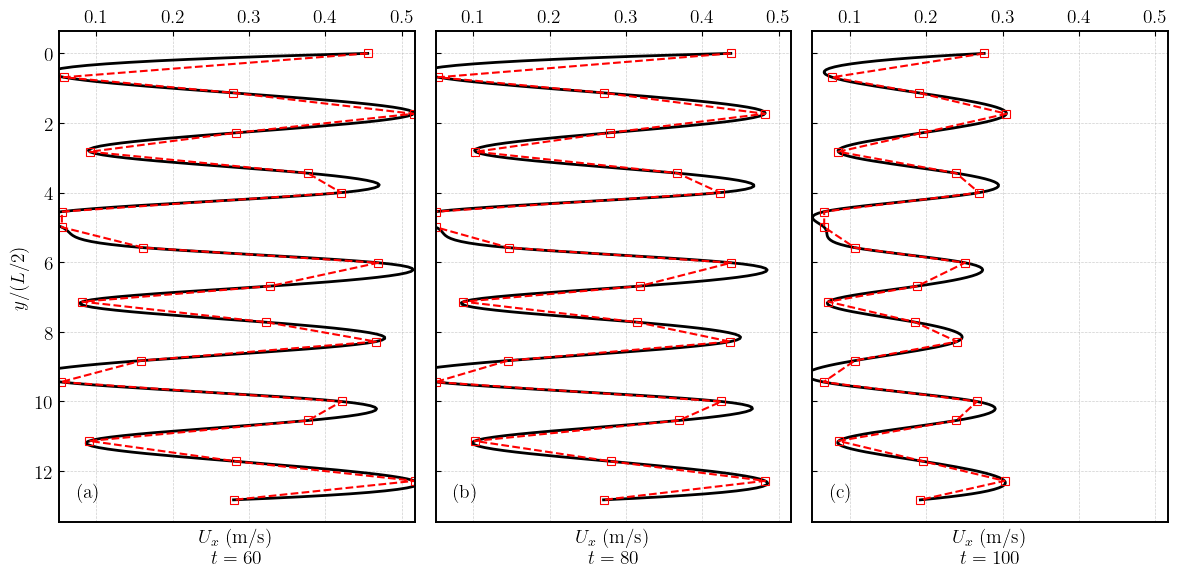

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# ===============================
# 数据
# ===============================
x = df["y/(L/2)"].values
t_list = [60, 80, 100]
panel_labels = ['(a)', '(b)', '(c)']

# 👉 统一 x 轴范围
Ux_min = min(df[f"t={t}"].min() for t in t_list)
Ux_max = max(df[f"t={t}"].max() for t in t_list)

# ===============================
# 画图参数
# ===============================
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    "text.usetex": True
})

fig, axes = plt.subplots(
    1, len(t_list),
    figsize=(12, 6),
    sharey=True
)

# ===============================
# 循环画图
# ===============================
for i, (ax, t) in enumerate(zip(axes, t_list)):

    y_t = df[f"t={t}"].values

    # ---------- 平滑曲线 ----------
    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        spl = make_interp_spline(x, y_t, k=3)
        y_smooth = spl(x_smooth)

        ax.plot(y_smooth, x_smooth, linewidth=2, color='black')
    else:
        ax.plot(y_t, x, linewidth=2, color='black')

    # ---------- 原始点 ----------
    ax.plot(
        y_t, x,
        linestyle='--',
        marker='s',
        markersize=6,
        markerfacecolor='none',
        markeredgewidth=0.8,
        color='red'
    )

    # ---------- 坐标轴 ----------
    ax.set_xlim(Ux_min, Ux_max)
    ax.invert_yaxis()
    ax.xaxis.tick_top()
    ax.yaxis.tick_left()

    ax.xaxis.set_tick_params(direction='in', which='both')
    ax.yaxis.set_tick_params(direction='in', which='both')

    # ---------- 标签 ----------
    ax.set_xlabel(
        rf'$U_x\;(\mathrm{{m/s}})$' + '\n' + rf'$t={t}$'
    )

    if i == 0:
        ax.set_ylabel(r'$y/(L/2)$')
    else:
        ax.tick_params(labelleft=False)
        ax.set_ylabel(None)

    # ---------- 子图标注 ----------
    ax.text(
        0.05, 0.05,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold'
    )

    # ---------- 网格 & 边框 ----------
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)

plt.tight_layout()
plt.show()


dict_keys(['triangle'])
Point Data Arrays: dict_keys(['U', 'Ux', 'p'])


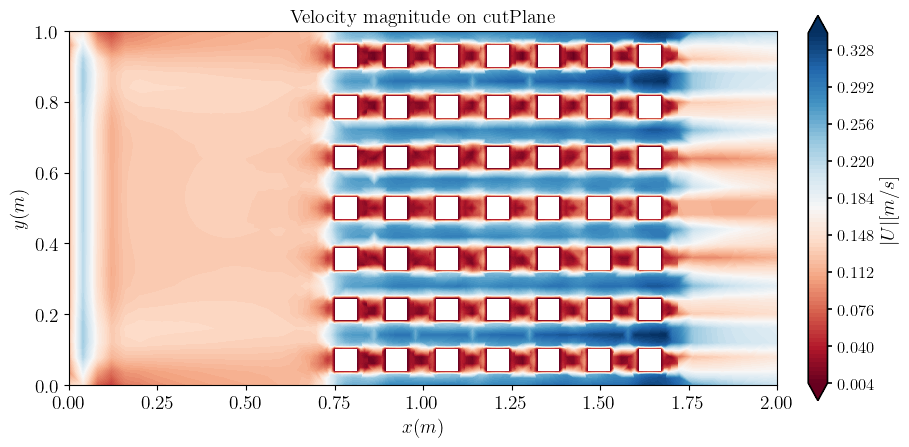

In [ ]:
import pyvista as pv
import meshio
import matplotlib.tri as tri
import os

poly = pv.read("t100.vtk")

# 2. 三角化（还是 PolyData）
poly_tri = poly.triangulate()

# 3. 转成 UnstructuredGrid（关键步骤）
ugrid = pv.UnstructuredGrid(poly_tri)

# 4. 保存成 VTK（现在是 UNSTRUCTURED_GRID 格式）
ugrid.save("cutPlane_tri.vtk")

# 5. 用 meshio 读取
mesh = meshio.read("cutPlane_tri.vtk")

print(mesh.cells_dict.keys())  # 应该有 triangle


# 检查有哪些 point_data 变量
print("Point Data Arrays:", mesh.point_data.keys())


# === 3. 选择你要画的字段 ===
# 假设是速度 U（向量），取大小

points = mesh.points
x = points[:, 0]

y = points[:, 1]

U = mesh.point_data['U']      # N x 3 数组

u, v = U[:, 0], U[:, 1]   # 取平面内的分量

magU = np.linalg.norm(U, axis=1)

# 如果是标量，比如压力 p
# magU = mesh.point_data['p']

# 取 log10（可选）
# magU = np.where(magU < 1e-12, -12., np.log10(magU))

# === 4. 获取单元拓扑信息 ===
# VTK 切面文件通常是三角形面（triangle）
cells = mesh.cells_dict.get("triangle")

if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元，可能是其他单元类型。")

# === 5. 构造 Triangulation ===
# 这里选择 x-z 平面作图（你也可以改成 x-y 或 y-z）

triang = tri.Triangulation(mesh.points[:, 0], mesh.points[:, 1], cells)

# === 6. 画等值图 ===
# 根据数据范围调整aspect ratio
x_range = 2 - x.min()
y_range = y.max() - y.min()
aspect_ratio = y_range / x_range

fig, ax = plt.subplots(figsize=(10, 10*aspect_ratio))  # 动态设置图形大小
ax.set_aspect('equal')

tpc = ax.tricontourf(triang, magU, cmap='RdBu', levels=100,extend='both')

# 画网格边界（可选）
# ax.triplot(triang, 'k-', linewidth=0.3)

ax.set_xlim(x.min(), 2.0)

# === 8. 美化颜色条 ===
cbar = fig.colorbar(tpc, ax=ax, orientation='vertical',
                    fraction=0.046, pad=0.04)  # 控制位置

cbar.set_label('$|U| [m/s]$', fontsize=14, fontweight='bold')

cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.set_tick_params(width=1.2)  # 刻度线粗细
cbar.outline.set_linewidth(1.2)           # 边框粗细

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 14}

plt.xlabel('$x (m)$', **ticklabel_style)
plt.ylabel('$y (m)$', **ticklabel_style)
plt.title('Velocity magnitude on cutPlane', **ticklabel_style)

#plt.savefig('cutPlane_colormap.png', dpi=400)
plt.show()




C:\Users\SCUT-WYX\AppData\Local\Temp\ipykernel_7920\2167298702.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


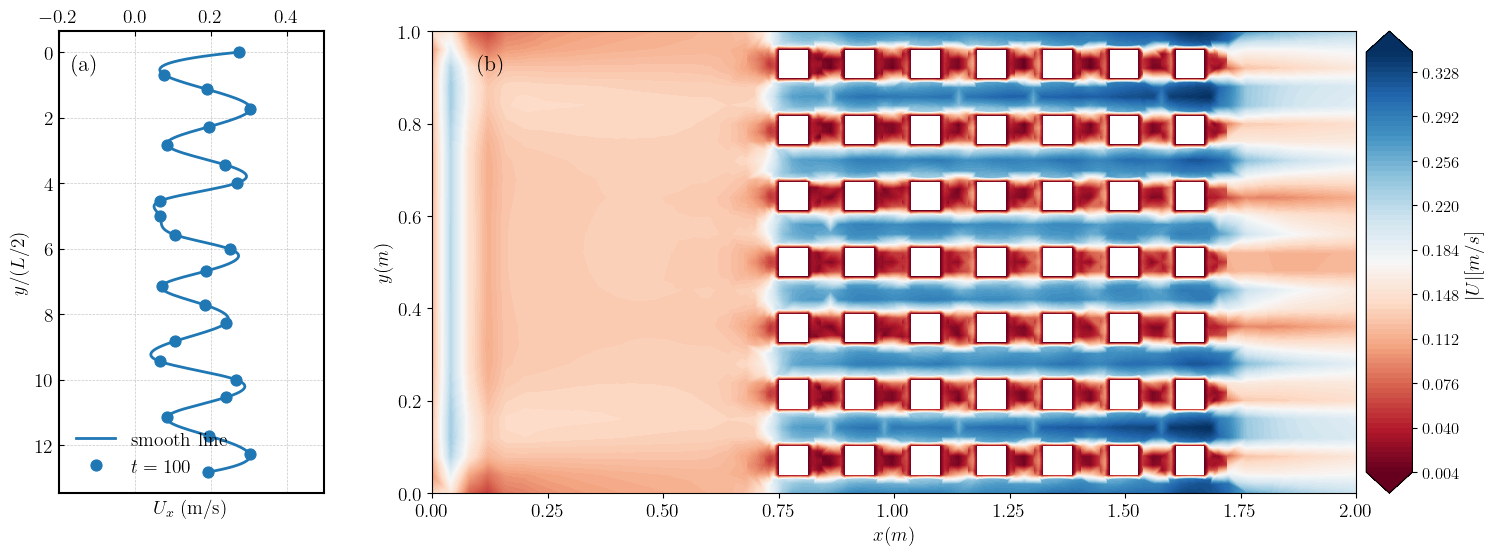

In [62]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.interpolate import make_interp_spline
import pyvista as pv
import meshio
import matplotlib.tri as tri

# ===============================
# 设置全局参数
# ===============================
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    "text.usetex": True
})

# ===============================
# 使用GridSpec创建不等宽子图
# ===============================
fig = plt.figure(figsize=(18, 6))
# 调整width_ratios，第一个数字是a图的比例，第二个是b图的比例
# 这里设置1:2，b图是a图的两倍宽
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 4], wspace=0.1)  # wspace控制子图间距

ax1 = plt.subplot(gs[0])  # 图(a)
ax2 = plt.subplot(gs[1])  # 图(b)

# ===============================
# 图 (a): 速度剖面图
# ===============================
# 数据准备 (假设df已经定义)
x = df["y/(L/2)"].values
t_col = "t=100"
y_t = df[t_col].values

# Experiment：插值平滑曲线
if len(x) > 3:
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spl = make_interp_spline(x, y_t, k=3)
    y_t_smooth = spl(x_smooth)
    ax1.plot(
        y_t_smooth, x_smooth,
        linewidth=2,
        linestyle='-',
        label='smooth line'
    )
else:
    ax1.plot(
        y_t, x,
        linewidth=2,
        linestyle='none',
        label='smooth line'
    )

# t=100：点线图
ax1.plot(
    y_t, x,
    linewidth=1.2,
    linestyle='none',
    marker='o',
    markersize=8,
    markerfacecolor='#1f77b4',
    markeredgewidth=0.8,
    color='#1f77b4',
    label=rf'$t=100$'
)

# 坐标轴设置
ax1.set_xlabel(r'$U_x\;(\mathrm{m/s})$')
ax1.set_ylabel(r'$y/(L/2)$')
ax1.invert_yaxis()          # y 轴刻度从上到下
ax1.yaxis.tick_left()       # y轴刻度在左侧
ax1.xaxis.tick_top()        # x轴刻度在上方
ax1.xaxis.set_tick_params(direction='in', which='both')
ax1.yaxis.set_tick_params(direction='in', which='both')
ax1.set_xlim(-0.2, 0.5)     # x 轴范围
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax1.legend(frameon=False, loc='lower left')

# 添加子图标签 (a)
ax1.text(0.05, 0.95, '(a)', transform=ax1.transAxes, 
         fontsize=16, fontweight='bold', va='top')

# ===============================
# 图 (b): 速度云图
# ===============================
# 读取和处理VTK数据
poly = pv.read("t100.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("cutPlane_tri.vtk")
mesh = meshio.read("cutPlane_tri.vtk")

# 提取数据
points = mesh.points
x_points = points[:, 0]
y_points = points[:, 1]
U = mesh.point_data['U']
magU = np.linalg.norm(U, axis=1)

# 获取三角形单元
cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

# 创建三角剖分
triang = tri.Triangulation(x_points, y_points, cells)

# 创建等值图
tpc = ax2.tricontourf(triang, magU, cmap='RdBu', levels=100, extend='both')
ax2.set_aspect('equal')
ax2.set_xlim(x_points.min(), 2.0)

# 添加颜色条
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(tpc, cax=cax)
cbar.set_label('$|U| [m/s]$', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# 坐标轴标签
ax2.set_xlabel('$x (m)$', fontname='Times New Roman', fontsize=14)
ax2.set_ylabel('$y (m)$', fontname='Times New Roman', fontsize=14)

# 添加子图标签 (b)
ax2.text(0.05, 0.95, '(b)', transform=ax2.transAxes, 
         fontsize=16, fontweight='bold', va='top')

# ===============================
# 调整布局并显示
# ===============================
plt.tight_layout()

# 保存图片（如果需要）
# plt.savefig('combined_figure.png', dpi=300, bbox_inches='tight')

plt.show()

       y   y/(L/2)       t=1       t=2       t=3       t=4       t=5  \
0  0.000  0.000000  0.126837  0.727889  1.119750  1.021920  0.987480   
1  0.049  0.685315  0.104943  0.103057  0.889530  0.619280  0.560327   
2  0.081  1.132867  0.115055  0.562763  0.826771  0.782272  0.693005   
3  0.124  1.734266  0.129249  0.770789  1.174720  1.072510  1.033910   
4  0.163  2.279720  0.117880  0.751505  0.887475  0.775352  0.730898   

        t=6       t=7       t=8  ...      t=91      t=92      t=93      t=94  \
0  0.978484  0.988122  1.070280  ...  0.270167  0.272682  0.273296  0.272976   
1  0.544029  0.547001  0.528752  ...  0.077458  0.076757  0.075869  0.075557   
2  0.674755  0.682590  0.683558  ...  0.189201  0.190113  0.189620  0.188825   
3  1.017330  1.029710  1.061750  ...  0.302721  0.306089  0.306635  0.304830   
4  0.712657  0.722205  0.734268  ...  0.197884  0.198056  0.196873  0.195539   

       t=95      t=96      t=97      t=98      t=99     t=100  
0  0.272795  0.273501 

C:\Users\SCUT-WYX\AppData\Local\Temp\ipykernel_19248\1249913917.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


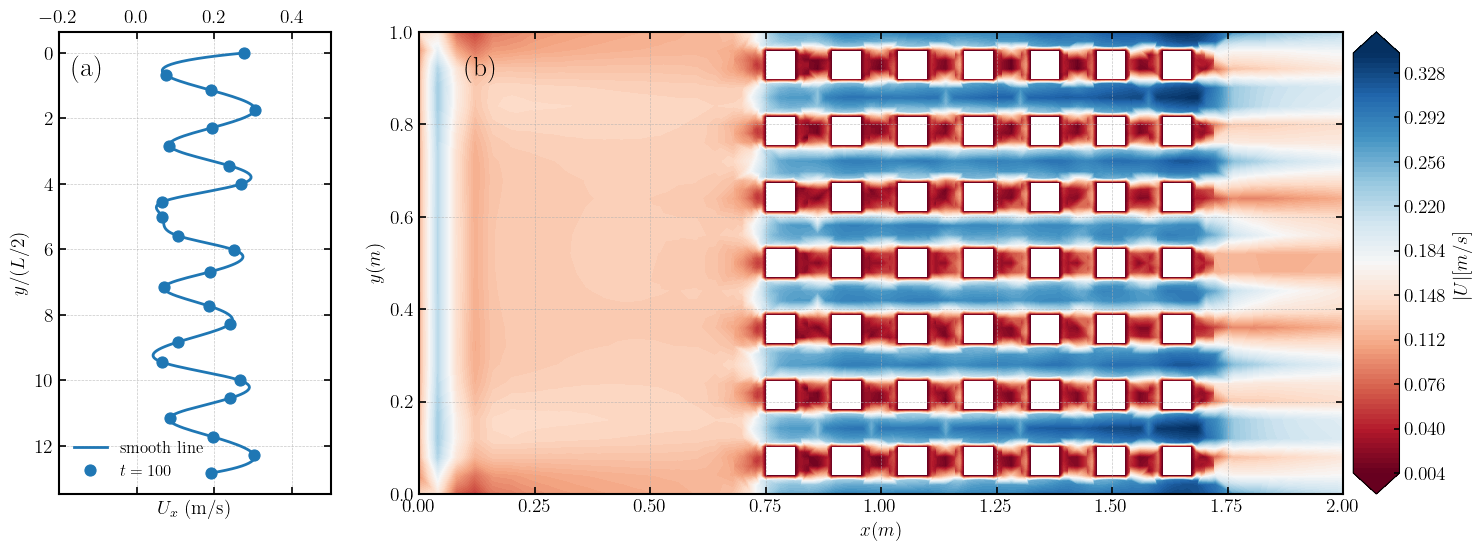

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.interpolate import make_interp_spline
import pyvista as pv
import meshio
import matplotlib.tri as tri
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

df = pd.read_csv('Ux.csv')

print(df.head())

# ===============================
# 设置全局参数
# ===============================
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    "text.usetex": True
})

# ===============================
# 使用GridSpec创建不等宽子图
# ===============================
fig = plt.figure(figsize=(18, 6))
# 调整width_ratios，第一个数字是a图的比例，第二个是b图的比例
# 这里设置1:4，b图是a图的四倍宽
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 4], wspace=0.05)  # wspace控制子图间距

ax1 = plt.subplot(gs[0])  # 图(a)
ax2 = plt.subplot(gs[1])  # 图(b)

# ===============================
# 统一边框和刻度设置函数
# ===============================
def set_axis_style(ax):
    """统一设置坐标轴样式"""
    # 设置刻度方向
    ax.xaxis.set_tick_params(direction='in', which='both', width=1.2, size=5)
    ax.yaxis.set_tick_params(direction='in', which='both', width=1.2, size=5)
    
    # 设置刻度位置
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    
    # 设置刻度标签字体
    ax.tick_params(axis='both', labelsize=14)
    
    # 设置边框线宽
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

# ===============================
# 图 (a): 速度剖面图
# ===============================
# 数据准备 (假设df已经定义)
x = df["y/(L/2)"].values
t_col = "t=100"
y_t = df[t_col].values

# Experiment：插值平滑曲线
if len(x) > 3:
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spl = make_interp_spline(x, y_t, k=3)
    y_t_smooth = spl(x_smooth)
    ax1.plot(
        y_t_smooth, x_smooth,
        linewidth=2,
        linestyle='-',
        label='smooth line'
    )
else:
    ax1.plot(
        y_t, x,
        linewidth=2,
        linestyle='none',
        label='smooth line'
    )

# t=100：点线图
ax1.plot(
    y_t, x,
    linewidth=1.2,
    linestyle='none',
    marker='o',
    markersize=8,
    markerfacecolor='#1f77b4',
    markeredgewidth=0.8,
    color='#1f77b4',
    label=rf'$t=100$'
)

# 坐标轴设置
ax1.set_xlabel(r'$U_x\;(\mathrm{m/s})$', fontsize=14)
ax1.set_ylabel(r'$y/(L/2)$', fontsize=14)
ax1.invert_yaxis()          # y 轴刻度从上到下
ax1.yaxis.tick_left()       # y轴刻度在左侧
ax1.xaxis.tick_top()        # x轴刻度在上方
ax1.set_xlim(-0.2, 0.5)     # x 轴范围
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# 应用统一的坐标轴样式
set_axis_style(ax1)

ax1.legend(frameon=False, loc='lower left', fontsize=12)

# 添加子图标签 (a) - 增大字号
ax1.text(0.05, 0.95, '(a)', transform=ax1.transAxes, 
         fontsize=20, fontweight='bold', va='top', ha='left')  # 增大到20

# ===============================
# 图 (b): 速度云图
# ===============================
# 读取和处理VTK数据
poly = pv.read("t100.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("cutPlane_tri.vtk")
mesh = meshio.read("cutPlane_tri.vtk")

# 提取数据
points = mesh.points
x_points = points[:, 0]
y_points = points[:, 1]
U = mesh.point_data['U']
u, v = U[:, 0], U[:, 1]   # 取平面内的分量
magU = np.linalg.norm(U, axis=1)

# 获取三角形单元
cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

# 创建三角剖分
triang = tri.Triangulation(x_points, y_points, cells)

# 创建等值图
tpc = ax2.tricontourf(triang, magU, cmap='RdBu', levels=100, extend='both')
ax2.set_aspect('equal')
ax2.set_xlim(x_points.min(), 2.0)

#from scipy.interpolate import griddata

""""
# === 7.1 建立规则网格用于 streamplot ===
nx, ny = 200, 200   # 网格分辨率，可调
xi = np.linspace(x_points.min(), x_points.max(), nx)
yi = np.linspace(y_points.min(), y_points.max(), ny)
XI, YI = np.meshgrid(xi, yi)

# 把速度场插值到规则网格
Ui = griddata(points[:, :2], u, (XI, YI), method='linear')
Vi = griddata(points[:, :2], v, (XI, YI), method='linear')

# === 7.2 画流线 ===
ax2.streamplot(
    XI, YI, Ui, Vi,
    color='k', density=3, linewidth=1, arrowsize=1
)
"""

# 应用统一的坐标轴样式
set_axis_style(ax2)

# 坐标轴标签
ax2.set_xlabel('$x (m)$', fontsize=14)
ax2.set_ylabel('$y (m)$', fontsize=14)

# 添加颜色条
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%", pad=0.1)

# 统一颜色条的边框样式
for spine in cax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

cbar = fig.colorbar(tpc, cax=cax)
cbar.set_label('$|U| [m/s]$', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14, direction='in', width=1.2)  # 统一刻度样式

# 添加子图标签 (b) - 增大字号
ax2.text(0.05, 0.95, '(b)', transform=ax2.transAxes, 
         fontsize=20, fontweight='bold', va='top', ha='left')  # 增大到20

# ===============================
# 统一网格线样式
# ===============================
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ===============================
# 调整布局并显示
# ===============================
plt.tight_layout()

# 保存图片（如果需要）
# plt.savefig('combined_figure.png', dpi=300, bbox_inches='tight')

plt.show()

dict_keys(['triangle'])
Point Data Arrays: dict_keys(['U', 'Ux', 'p'])


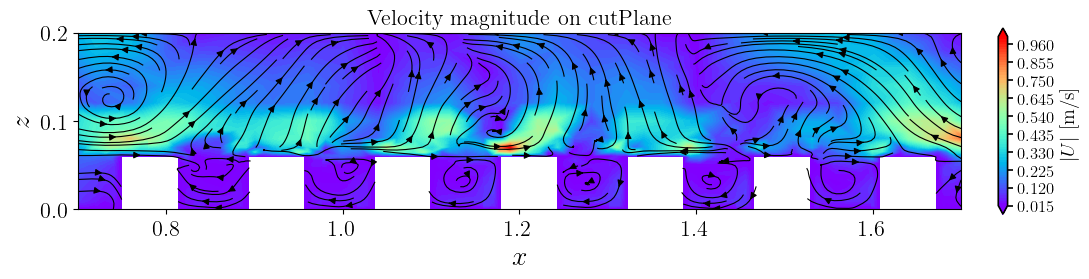

In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.interpolate import make_interp_spline
import pyvista as pv
import meshio
import matplotlib.tri as tri
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 5. 用 meshio 读取

poly = pv.read("t100_y.vtk")

# 2. 三角化（还是 PolyData）
poly_tri = poly.triangulate()

# 3. 转成 UnstructuredGrid（关键步骤）
ugrid = pv.UnstructuredGrid(poly_tri)

# 4. 保存成 VTK（现在是 UNSTRUCTURED_GRID 格式）
ugrid.save("t100_y_u.vtk")

# 5. 用 meshio 读取
mesh = meshio.read("t100_y_u.vtk")

print(mesh.cells_dict.keys())  # 应该有 triangle

# 获取节点坐标
points = mesh.points
x = points[:, 0]
z = points[:, 2]


# === 1. Matplotlib 全局字体设置 ===
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ['Times New Roman'],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "text.usetex": True,
    "figure.figsize": (12, 5)})

ticklabel_style = {"fontname": "Times New Roman", "fontsize": 16}

# 检查有哪些 point_data 变量
print("Point Data Arrays:", mesh.point_data.keys())

# === 3. 选择你要画的字段 ===
# 假设是速度 U（向量），取大小
U = mesh.point_data['U']      # N x 3 数组

u, v = U[:, 0], U[:, 2]   # 取平面内的分量

magU = np.linalg.norm(U, axis=1)

# 如果是标量，比如压力 p
# magU = mesh.point_data['p']

# 取 log10（可选）
# magU = np.where(magU < 1e-12, -12., np.log10(magU))

# === 4. 获取单元拓扑信息 ===
# VTK 切面文件通常是三角形面（triangle）
cells = mesh.cells_dict.get("triangle")

if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元，可能是其他单元类型。")

# === 5. 构造 Triangulation ===
# 这里选择 x-z 平面作图（你也可以改成 x-y 或 y-z）

triang = tri.Triangulation(mesh.points[:, 0], mesh.points[:, 2], cells)

# === 6. 画等值图 ===
fig, ax = plt.subplots()
ax.set_aspect('equal')

tpc = ax.tricontourf(triang, magU, cmap='rainbow', levels=100,extend='both')

# 画网格边界（可选）
# ax.triplot(triang, 'k-', linewidth=0.3)

# === 7. 添加流场箭头（稀疏取点防止太密） ===
#skip = 5  # 每隔10个点取一个
#ax.quiver(
#    x[::skip], y[::skip],
#    u[::skip], v[::skip],
#    color='k', scale=40, width=0.0025
#)

from scipy.interpolate import griddata

# === 7.1 建立规则网格用于 streamplot ===
# 注意：这里应该是x-z平面，所以用x和z的范围
nx, nz = 200, 200   # 网格分辨率
xi = np.linspace(0.7, 1.7, nx)
zi = np.linspace(0, 0.2, nz)  # 注意：这里是z，不是y
XI, ZI = np.meshgrid(xi, zi)

# 把速度场插值到规则网格
# 使用x和z坐标作为插值点
Ui = griddata(points[:, [0, 2]], u, (XI, ZI), method='linear')
Vi = griddata(points[:, [0, 2]], v, (XI, ZI), method='linear')

# === 7.2 画流线 ===
# 修改streamplot的参数
ax.streamplot(
    XI, ZI, Ui, Vi,  # 注意：这里是ZI而不是YI
    color='k', density=2, linewidth=0.8, arrowsize=1
)


#ax.set_xlim(x.min(), x.max())
#ax.set_ylim(z.min(), z.max())

ax.set_xlim(0.7, 1.7)
ax.set_ylim(0, 0.2)

# === 8. 美化颜色条 ===
cbar = fig.colorbar(tpc, ax=ax, orientation='vertical',
                    fraction=0.01, pad=0.04)  # 控制位置

cbar.set_label('$|U|$ [m/s]', fontsize=14, fontweight='bold')

cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.set_tick_params(width=1.2)  # 刻度线粗细
cbar.outline.set_linewidth(1.2)           # 边框粗细

plt.xlabel(r'$x$',fontsize=20)
plt.ylabel(r'$z$',fontsize=20)
plt.title('Velocity magnitude on cutPlane', **ticklabel_style)

#plt.savefig('aq_cutPlane_colormap.png', dpi=400,bbox_inches='tight')
plt.show()


       y   y/(L/2)       t=1       t=2       t=3       t=4       t=5  \
0  0.000  0.000000  0.126837  0.727889  1.119750  1.021920  0.987480   
1  0.049  0.685315  0.104943  0.103057  0.889530  0.619280  0.560327   
2  0.081  1.132867  0.115055  0.562763  0.826771  0.782272  0.693005   
3  0.124  1.734266  0.129249  0.770789  1.174720  1.072510  1.033910   
4  0.163  2.279720  0.117880  0.751505  0.887475  0.775352  0.730898   

        t=6       t=7       t=8  ...      t=91      t=92      t=93      t=94  \
0  0.978484  0.988122  1.070280  ...  0.270167  0.272682  0.273296  0.272976   
1  0.544029  0.547001  0.528752  ...  0.077458  0.076757  0.075869  0.075557   
2  0.674755  0.682590  0.683558  ...  0.189201  0.190113  0.189620  0.188825   
3  1.017330  1.029710  1.061750  ...  0.302721  0.306089  0.306635  0.304830   
4  0.712657  0.722205  0.734268  ...  0.197884  0.198056  0.196873  0.195539   

       t=95      t=96      t=97      t=98      t=99     t=100  
0  0.272795  0.273501 

C:\Users\SCUT-WYX\AppData\Local\Temp\ipykernel_30572\3983749412.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


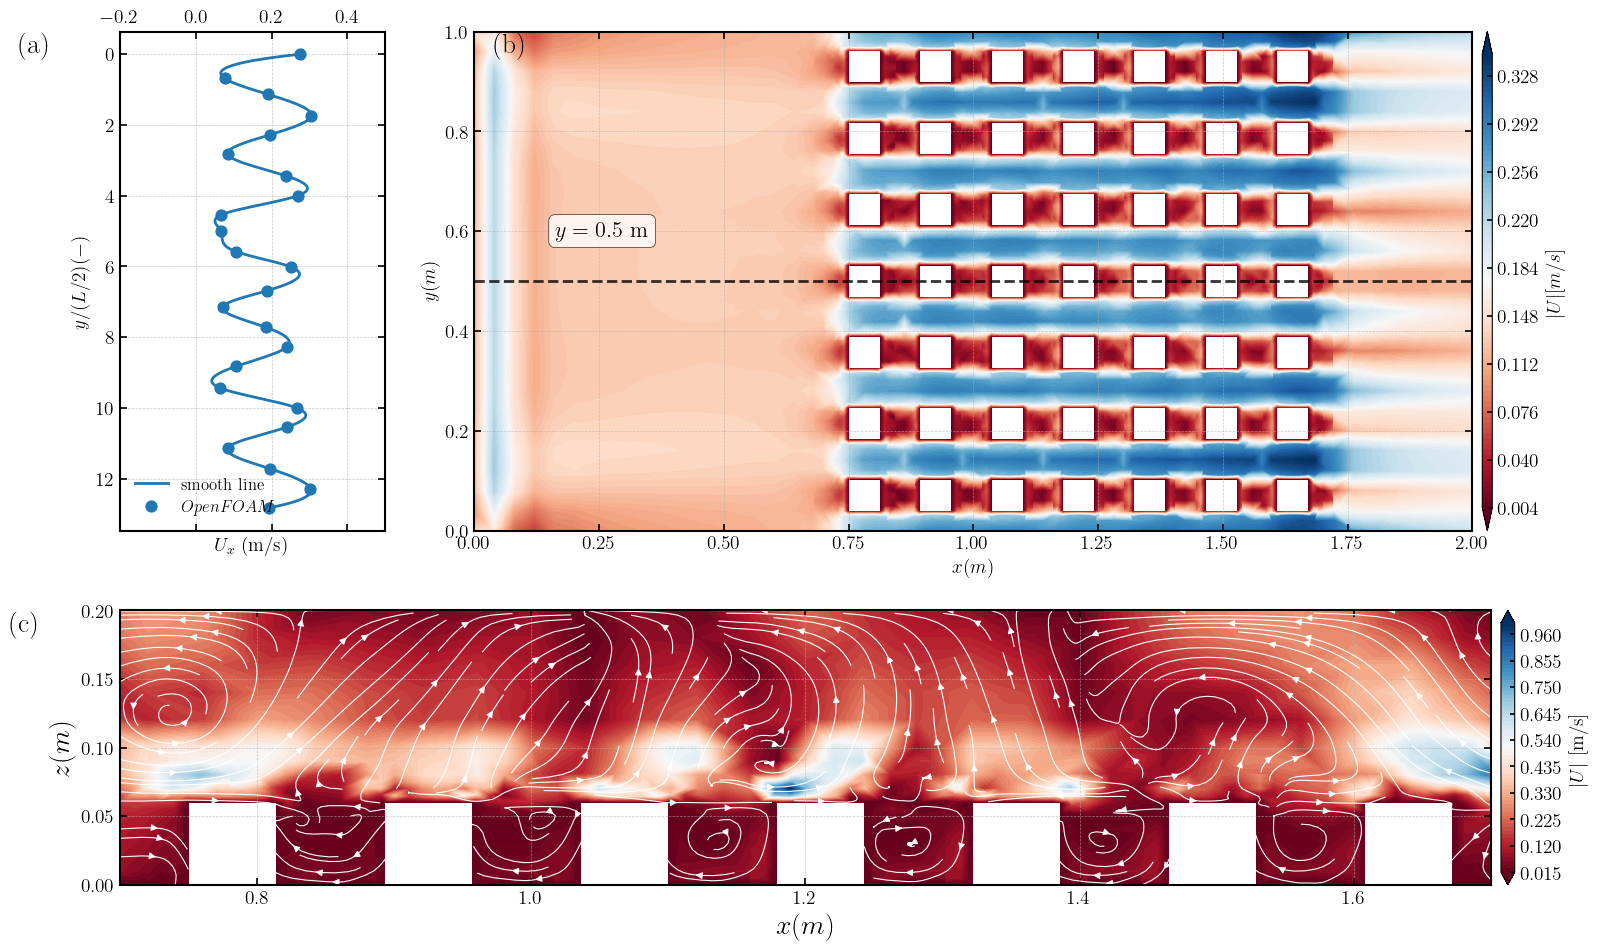

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.interpolate import make_interp_spline, griddata
import pyvista as pv
import meshio
import matplotlib.tri as tri
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

# ===============================
# 设置全局参数
# ===============================
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    "text.usetex": True
})

# ===============================
# 创建2行布局：第1行有2个子图(a,b)，第2行有1个子图(c)
# ===============================
fig = plt.figure(figsize=(18, 12))

# 创建GridSpec：2行，第1行2列，第2行1列
# 高度比例：第1行占6，第2行占6
gs = gridspec.GridSpec(2, 2, height_ratios=[6, 5], width_ratios=[1, 4], 
                      hspace=0.02, wspace=0.1)

# 分配子图位置
ax1 = plt.subplot(gs[0, 0])  # 第0行，第0列 - 图(a)
ax2 = plt.subplot(gs[0, 1])  # 第0行，第1列 - 图(b)
ax3 = plt.subplot(gs[1, :])  # 第1行，占整行 - 图(c)

# ===============================
# 统一边框和刻度设置函数
# ===============================
def set_axis_style(ax):
    """统一设置坐标轴样式"""
    # 设置刻度方向
    ax.xaxis.set_tick_params(direction='in', which='both', width=1.2, size=5)
    ax.yaxis.set_tick_params(direction='in', which='both', width=1.2, size=5)
    
    # 设置刻度位置
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    
    # 设置刻度标签字体
    ax.tick_params(axis='both', labelsize=14)
    
    # 设置边框线宽
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

# ===============================
# 图 (a): 速度剖面图
# ===============================
# 数据准备 (假设df已经定义)

df = pd.read_csv('Ux.csv')
print(df.head())

x = df["y/(L/2)"].values
t_col = "t=100"
y_t = df[t_col].values

# Experiment：插值平滑曲线
if len(x) > 3:
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spl = make_interp_spline(x, y_t, k=3)
    y_t_smooth = spl(x_smooth)
    ax1.plot(
        y_t_smooth, x_smooth,
        linewidth=2,
        linestyle='-',
        label='smooth line'
    )
else:
    ax1.plot(
        y_t, x,
        linewidth=2,
        linestyle='none',
        label='smooth line'
    )

# t=100：点线图
ax1.plot(
    y_t, x,
    linewidth=1.2,
    linestyle='none',
    marker='o',
    markersize=8,
    markerfacecolor='#1f77b4',
    markeredgewidth=0.8,
    color='#1f77b4',
    label=rf'$OpenFOAM$'
)

# 坐标轴设置
ax1.set_xlabel(r'$U_x\;(\mathrm{m/s})$', fontsize=14)
ax1.set_ylabel(r'$y/(L/2) (-)$', fontsize=14)
ax1.invert_yaxis()          # y 轴刻度从上到下
ax1.yaxis.tick_left()       # y轴刻度在左侧
ax1.xaxis.tick_top()        # x轴刻度在上方
ax1.set_xlim(-0.2, 0.5)     # x 轴范围
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# 应用统一的坐标轴样式
set_axis_style(ax1)

ax1.legend(frameon=False, loc='lower left', fontsize=12)

# 添加子图标签 (a) - 增大字号
ax1.text(-0.38, 1.0, '(a)', transform=ax1.transAxes, 
         fontsize=20, fontweight='bold', va='top', ha='left')

# ===============================
# 图 (b): 速度云图 (x-y平面)
# ===============================
# 读取和处理VTK数据
poly = pv.read("t100.vtk")
poly_tri = poly.triangulate()
ugrid = pv.UnstructuredGrid(poly_tri)
ugrid.save("cutPlane_tri.vtk")
mesh = meshio.read("cutPlane_tri.vtk")

# 提取数据
points = mesh.points
x_points = points[:, 0]
y_points = points[:, 1]
U = mesh.point_data['U']
magU = np.linalg.norm(U, axis=1)

# 获取三角形单元
cells = mesh.cells_dict.get("triangle")
if cells is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

# 创建三角剖分
triang = tri.Triangulation(x_points, y_points, cells)

# 创建等值图
tpc = ax2.tricontourf(triang, magU, cmap='RdBu', levels=100, extend='both')
ax2.set_aspect('equal')
ax2.set_xlim(x_points.min(), 2.0)

# 添加水平虚线
ax2.axhline(y=0.5, xmin=0, xmax=1, 
            color='black',        # 黑色虚线
            linestyle='--',       # 虚线样式
            linewidth=2,          # 线宽
            alpha=0.8,            # 透明度
            zorder=10)            # 确保在云图上方

ax2.text(0.35, 0.6,             # x=图形右侧，y=0.5
         r'$y = 0.5\ \mathrm{m}$',  # 文字内容
         fontsize=16,            # 字体大小
         fontweight='bold',      # 加粗
         color='black',          # 黑色文字
         verticalalignment='center',  # 垂直居中
         horizontalalignment='right', # 右对齐
         transform=ax2.transData,    # 使用数据坐标
         bbox=dict(boxstyle='round,pad=0.3',  # 圆角文本框
                   facecolor='white',         # 白色背景
                   edgecolor='black',         # 黑色边框
                   alpha=0.8,                 # 透明度
                   linewidth=0.5),            # 边框线宽
         zorder=11)             # 确保在虚线上方

# 应用统一的坐标轴样式
set_axis_style(ax2)

# 坐标轴标签
ax2.set_xlabel('$x (m)$', fontsize=14)
ax2.set_ylabel('$y (m)$', fontsize=14)

# 添加颜色条
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="1%", pad=0.1)

# 统一颜色条的边框样式
for spine in cax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

cbar = fig.colorbar(tpc, cax=cax)
cbar.set_label('$|U| [m/s]$', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=14, direction='in', width=1.2)  # 统一刻度样式

# 添加子图标签 (b)
ax2.text(0.02, 1.00, '(b)', transform=ax2.transAxes, 
         fontsize=20, fontweight='bold', va='top', ha='left')

# ===============================
# 图 (c): 速度云图 + 流线 (x-z平面)
# ===============================
# 读取和处理VTK数据
poly_c = pv.read("t100_y.vtk")
poly_tri_c = poly_c.triangulate()
ugrid_c = pv.UnstructuredGrid(poly_tri_c)
ugrid_c.save("t100_y_u.vtk")
mesh_c = meshio.read("t100_y_u.vtk")

print("图(c)的单元类型:", mesh_c.cells_dict.keys())

# 提取数据
points_c = mesh_c.points
x_c = points_c[:, 0]
z_c = points_c[:, 2]

# 检查point_data
print("图(c)的Point Data Arrays:", mesh_c.point_data.keys())

U_c = mesh_c.point_data['U']
u_c = U_c[:, 0]
v_c = U_c[:, 2]  # z方向分量
magU_c = np.linalg.norm(U_c, axis=1)

# 获取三角形单元
cells_c = mesh_c.cells_dict.get("triangle")
if cells_c is None:
    raise ValueError("VTK 文件中没有 triangle 单元")

# 创建三角剖分
triang_c = tri.Triangulation(points_c[:, 0], points_c[:, 2], cells_c)

# 创建等值图
tpc_c = ax3.tricontourf(triang_c, magU_c, cmap='RdBu', levels=100, extend='both')
ax3.set_aspect('equal')

# 添加流线图
# 建立规则网格用于streamplot
nx, nz = 200, 200
xi = np.linspace(0.7, 1.7, nx)
zi = np.linspace(0, 0.2, nz)
XI, ZI = np.meshgrid(xi, zi)

# 把速度场插值到规则网格
Ui = griddata(points_c[:, [0, 2]], u_c, (XI, ZI), method='linear')
Vi = griddata(points_c[:, [0, 2]], v_c, (XI, ZI), method='linear')

# 画流线
ax3.streamplot(
    XI, ZI, Ui, Vi,
    color='white', density=2, linewidth=0.8, arrowsize=1
)

# 设置坐标轴范围
ax3.set_xlim(0.7, 1.7)
ax3.set_ylim(0, 0.2)

# 应用统一的坐标轴样式
set_axis_style(ax3)

# 坐标轴标签
ax3.set_xlabel(r'$x (m)$', fontsize=20)
ax3.set_ylabel(r'$z (m)$', fontsize=20)

# 添加颜色条
divider_c = make_axes_locatable(ax3)
cax_c = divider_c.append_axes("right", size="1%", pad=0.1)

# 统一颜色条的边框样式
for spine in cax_c.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

cbar_c = fig.colorbar(tpc_c, cax=cax_c)
cbar_c.set_label('$|U|$ [m/s]', fontsize=14, fontweight='bold')
cbar_c.ax.tick_params(labelsize=14, direction='in', width=1.2)

# 添加子图标签 (c)
ax3.text(-0.08, 1.0, '(c)', transform=ax3.transAxes, 
         fontsize=20, fontweight='bold', va='top', ha='left')


# ===============================
# 统一网格线样式
# ===============================
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# ===============================
# 调整布局并显示
# ===============================
plt.tight_layout()

# 保存图片（如果需要）
plt.savefig('Fig4.jpg', dpi=600, bbox_inches='tight')

plt.show()

In [ ]:
# 1. 提取相分数数据 (假设 VTK 中有 alpha.water)
# 读取和处理VTK数据


poly = pv.read("cutPlane2.vtk")

# 2. 三角化（还是 PolyData）
poly_tri = poly.triangulate()

# 3. 转成 UnstructuredGrid（关键步骤）
ugrid = pv.UnstructuredGrid(poly_tri)

# 4. 保存成 VTK（现在是 UNSTRUCTURED_GRID 格式）
ugrid.save("cutPlane_tri2.vtk")

# 5. 用 meshio 读取
mesh = meshio.read("cutPlane_tri2.vtk")

print(mesh.cells_dict.keys())  # 应该有 triangle


# 检查有哪些 point_data 变量
print("Point Data Arrays:", mesh.point_data.keys())


mesh_d = meshio.read("cutPlane_tri2.vtk")

print("图(d)的单元类型:", mesh_d.cells_dict.keys())


alpha = mesh_d.point_data['alpha.water'] 

# 2. 对速度场进行遮罩处理
# 创建一个副本，将 alpha < 0.5 (空气) 的部分设为 NaN
magU_masked = np.copy(magU_c)
magU_masked[alpha < 0.5] = np.nan 

# 3. 绘图时使用遮罩后的数据
# 1. 提取相分数

# 2. 创建三角剖分对象
triang_c = tri.Triangulation(points_c[:, 0], points_c[:, 2], cells_c)

# 3. 计算每个三角形中心的 alpha 值，用于掩码处理
# cells_c 是 (N, 3) 的阵，代表三角形的三个顶点索引
alpha_faces = np.mean(alpha[cells_c], axis=1)

# 4. 设置掩码：如果三角形中心的 alpha < 0.5，则隐藏该三角形
# 这样云图就只会显示在“水”所在的区域
triang_c.set_mask(alpha_faces < 0.5)

# 5. 绘图（此时使用原始的 magU_c，不再需要设为 NaN）
tpc_c = ax3.tricontourf(triang_c, magU_c, cmap='RdBu', levels=100, extend='both')

# 6. (可选) 绘制液面轮廓线 (自由表面)
# 注意：画轮廓线时建议使用未被 mask 的原始三角剖分，否则线会断开
triang_unmasked = tri.Triangulation(points_c[:, 0], points_c[:, 2], cells_c)
ax3.tricontour(triang_unmasked, alpha, levels=[0.5], colors='black', linewidths=1.5)



dict_keys(['triangle'])
Point Data Arrays: dict_keys(['U', 'Ux', 'alpha.water', 'enstrophy', 'p', 'vorticity'])
图(d)的单元类型: dict_keys(['triangle'])


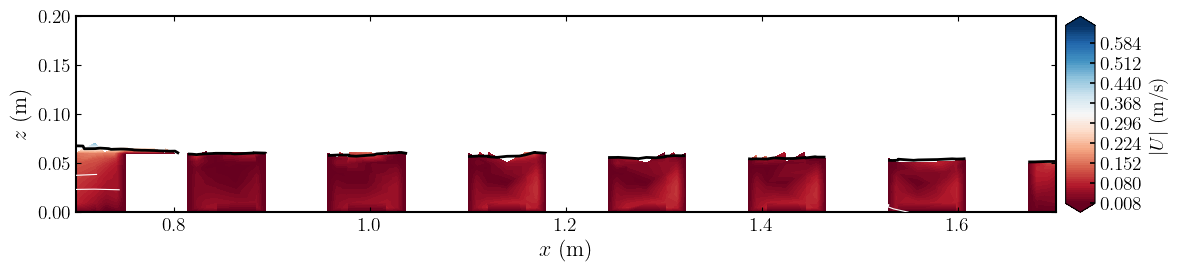

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.tri as tri
import numpy as np
import meshio
from scipy.interpolate import griddata

# ===============================
# 1. 基础配置
# ===============================
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    'text.usetex': True
})

fig, ax3 = plt.subplots(figsize=(12, 5))

# ===============================
# 2. 读取数据 (请确保文件名正确)
# ===============================
# 假设你已经按照之前的步骤生成了 cutPlane_tri2.vtk
mesh_d = meshio.read("cutPlane_tri2.vtk")
points_c = mesh_d.points
cells_c = mesh_d.cells_dict["triangle"]

# 提取物理量
U_c = mesh_d.point_data['U']
magU_c = np.linalg.norm(U_c, axis=1)
alpha_c = mesh_d.point_data['alpha.water'] # 确保变量名在VTK中存在
u_c = U_c[:, 0]
w_c = U_c[:, 2] # z方向速度

# ===============================
# 3. 核心：创建带掩码(Mask)的三角剖分
# ===============================
triang_c = tri.Triangulation(points_c[:, 0], points_c[:, 2], cells_c)

# 计算每个三角形三个顶点 alpha 的平均值
alpha_faces = np.mean(alpha_c[cells_c], axis=1)

# 设置掩码：alpha < 0.5 的三角形将被隐藏（不渲染速度颜色）
triang_c.set_mask(alpha_faces < 0.5)

# ===============================
# 4. 绘图：速度云图
# ===============================
# 绘制水相区域的速度场
tpc_c = ax3.tricontourf(triang_c, magU_c, cmap='RdBu', levels=100, extend='both')
ax3.set_aspect('equal')

# 绘制液面轮廓线 (alpha = 0.5 的黑线)
# 注意：这里使用原始未掩码的剖分，否则线会因为掩码而断裂
triang_raw = tri.Triangulation(points_c[:, 0], points_c[:, 2], cells_c)
ax3.tricontour(triang_raw, alpha_c, levels=[0.5], colors='black', linewidths=2.0, zorder=5)

# ===============================
# 5. 绘图：流线 (只在水中绘制)
# ===============================
nx, nz = 600, 450
xi = np.linspace(points_c[:,0].min(), points_c[:,0].max(), nx)
zi = np.linspace(points_c[:,2].min(), points_c[:,2].max(), nz)
XI, ZI = np.meshgrid(xi, zi)

# 插值速度和相分数到规则网格
Ui = griddata(points_c[:, [0, 2]], u_c, (XI, ZI), method='linear')
Wi = griddata(points_c[:, [0, 2]], w_c, (XI, ZI), method='linear')
Ai = griddata(points_c[:, [0, 2]], alpha_c, (XI, ZI), method='linear')

# 将空气区域 (Ai < 0.5) 的速度设为 NaN，streamplot 会自动忽略这些区域
Ui[Ai < 0.5] = np.nan
Wi[Ai < 0.5] = np.nan

# 画白色流线
ax3.streamplot(XI, ZI, Ui, Wi, color='white', density=2, linewidth=0.8, arrowsize=1, zorder=4)

# ===============================
# 6. 后端修饰 (坐标轴与颜色条)
# ===============================
ax3.set_xlabel(r'$x$ (m)', fontsize=16)
ax3.set_ylabel(r'$z$ (m)', fontsize=16)
ax3.set_xlim(0.7, 1.7)
ax3.set_ylim(0, 0.2)

# 设置刻度样式
ax3.tick_params(direction='in', which='both', top=True, right=True, labelsize=14)
for spine in ax3.spines.values():
    spine.set_linewidth(1.5)

# 添加颜色条
divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="3%", pad=0.1)
cbar = fig.colorbar(tpc_c, cax=cax)
cbar.set_label(r'$|U|$ (m/s)', fontsize=14)
cbar.ax.tick_params(direction='in', width=1.2)

plt.tight_layout()
plt.savefig('Result_C_Only.jpg', dpi=300)
plt.show()

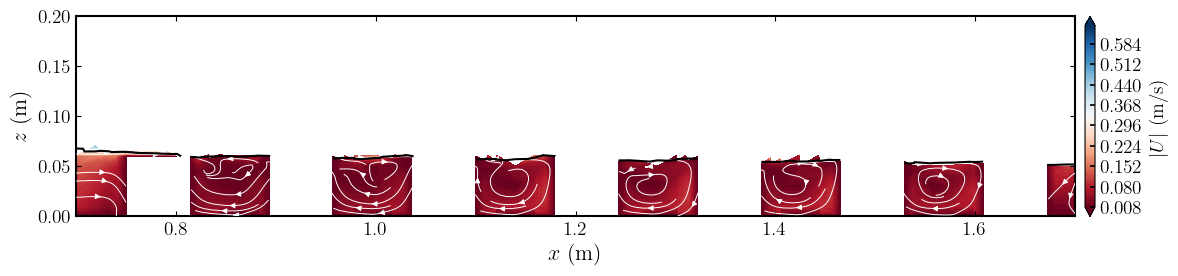

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.tri as tri
import numpy as np
import meshio
from scipy.interpolate import griddata

# ===============================
# 1. 基础配置
# ===============================
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    'text.usetex': True
})

fig, ax3 = plt.subplots(figsize=(12, 5))

# ===============================
# 2. 读取数据
# ===============================
mesh_d = meshio.read("cutPlane_tri2.vtk")
points_c = mesh_d.points
cells_c = mesh_d.cells_dict["triangle"]

U_c = mesh_d.point_data['U']
magU_c = np.linalg.norm(U_c, axis=1)
alpha_c = mesh_d.point_data['alpha.water'] 
u_c = U_c[:, 0]
w_c = U_c[:, 2] 

# ===============================
# 3. 绘图：流线预处理 (根据 alpha 物理截断)
# ===============================
# 提高网格密度以获得更平滑的流线
nx, nz = 600, 450
xi = np.linspace(0.7, 1.7, nx)
zi = np.linspace(0, 0.2, nz)
XI, ZI = np.meshgrid(xi, zi)

# 插值
Ui = griddata(points_c[:, [0, 2]], u_c, (XI, ZI), method='linear')
Wi = griddata(points_c[:, [0, 2]], w_c, (XI, ZI), method='linear')
Ai = griddata(points_c[:, [0, 2]], alpha_c, (XI, ZI), method='linear')

# --- 关键修改：如果你想让流线精准停在液面 ---
# 只有 alpha > 0.1 的地方才允许流线存在（可以微调 0.1 这个阈值）
# 这样即便你“先”画流线，它们在视觉上也只存在于水相中
Ui[Ai < 0.1] = np.nan
Wi[Ai < 0.1] = np.nan

# 绘制白色流线
# 放到 zorder=4 确保它在云图之上
ax3.streamplot(XI, ZI, Ui, Wi, color='white', density=2.5, linewidth=0.7, arrowsize=0.8, zorder=4)

# ===============================
# 4. 绘图：带 Mask 的速度云图
# ===============================
triang_c = tri.Triangulation(points_c[:, 0], points_c[:, 2], cells_c)
alpha_faces = np.mean(alpha_c[cells_c], axis=1)
triang_c.set_mask(alpha_faces < 0.5) # 遮掉空气区的颜色

# 绘制云图
tpc_c = ax3.tricontourf(triang_c, magU_c, cmap='RdBu', levels=100, extend='both', zorder=1)
ax3.set_aspect('equal')

# 绘制液面轮廓线 (alpha = 0.5)
triang_raw = tri.Triangulation(points_c[:, 0], points_c[:, 2], cells_c)
ax3.tricontour(triang_raw, alpha_c, levels=[0.5], colors='black', linewidths=1.5, zorder=5)

# ===============================
# 5. 后端修饰
# ===============================
ax3.set_xlabel(r'$x$ (m)', fontsize=16)
ax3.set_ylabel(r'$z$ (m)', fontsize=16)
ax3.set_xlim(0.7, 1.7)
ax3.set_ylim(0, 0.2)

# 设置背景色为浅灰色，方便区分空气区（可选）
#ax3.set_facecolor('#66ccff') 

ax3.tick_params(direction='in', which='both', top=True, right=True, labelsize=14)
for spine in ax3.spines.values():
    spine.set_linewidth(1.5)

divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="1%", pad=0.1)
cbar = fig.colorbar(tpc_c, cax=cax)
cbar.set_label(r'$|U|$ (m/s)', fontsize=14)
cbar.ax.tick_params(direction='in', width=1.2)

plt.tight_layout()
plt.savefig('Result_C_Masked_Streamlines.jpg', dpi=300,bbox_inches='tight')
plt.show()